<a href="https://colab.research.google.com/github/Rishav-134/Matchine-learning/blob/main/EDAPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np



In [ ]:
from types import SimpleNamespace
import seaborn as sns
df=sns.load_dataset("titanic")
# df.shape
# df.columns
# df.tail()
# df[['survived', 'alive']].head()
extra_col= df.drop(['class','who','alive','deck'],axis=1,inplace=True)
# df.columns
numbered_col=list(df.select_dtypes(include='number'))
# # display(numbered_col)
# # df.info()
# # df.describe()
df.isnull().sum()
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()
# df.head()
# df['sibsp'].value_counts()
# df['sibsp'].unique()
# df['parch'].value_counts()


/tmp/ipykernel_4700/2425793816.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_4700/2425793816.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

np.int64(0)

In [ ]:
import matplotlib.pyplot as plt
# for col in numbered_col:
#     plt.figure(figsize=(6,4))
#     sns.histplot(df[col],kde=True)
#     plt.show()
# df['age'].skew()
import seaborn as sns
# sns.heatmap(df[numbered_col].corr(),annot=True)
# plt.show()
# sns.pairplot(df
# sns.countplot(x='sex', hue='survived', data=df)
# sns.countplot(x='pclass', hue='survived', data=df)
# # sns.countplot(x='embarked', hue='survived', data=df)

# sns.boxplot(x=df['age'])
# sns.boxplot(x=df['fare'])
df.groupby('pclass')['survived'].mean()*100





,survived
pclass,
1,63.333333
2,50.609756
3,25.935162


### Handling Outliers in 'age' using IQR method

<Axes: xlabel='age'>

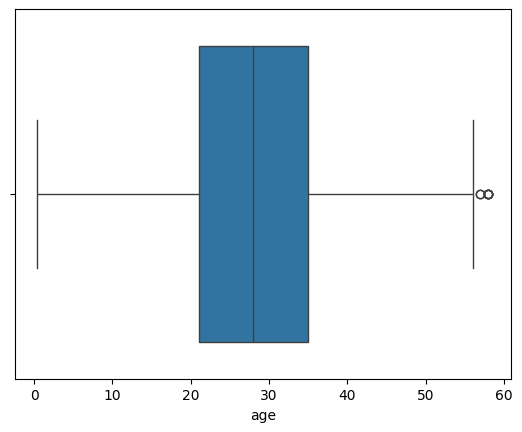

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'age'
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)

# Calculate IQR
IQR_age = Q3_age - Q1_age

# Define bounds for outliers
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

# Filter out the outliers
df_no_outliers_age = df[(df['age'] >= lower_bound_age) & (df['age'] <= upper_bound_age)]
sns.boxplot(x=df_no_outliers_age['age'])


<Axes: xlabel='fare'>

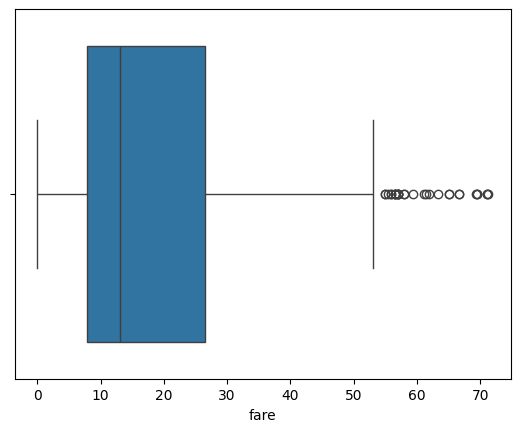

In [ ]:
Q1_fare = df['fare'].quantile(0.25)
Q3_fare = df['fare'].quantile(0.75)

# Calculate IQR
IQR_fare = Q3_fare - Q1_fare

# Define bounds for outliers
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

# Filter out the outliers
df_no_outliers_fare = df[(df['fare'] >= lower_bound_fare) & (df['fare'] <= upper_bound_fare)]
sns.boxplot(x=df_no_outliers_fare['fare'])

In [ ]:
from pandas.core.indexes.multi import maybe_droplevels
df['family_size']=df['sibsp']+df['parch']+1
df.drop(['sibsp','parch'],axis=1,inplace=True)
df.head()
# df['embark_town'].unique()
df['is_alone'] = df['alone'].astype(int)
df.drop('alone',axis=1,inplace=True)
df['is_adultmale'] = df['adult_male'].astype(int)
df.drop('adult_male',axis=1,inplace=True)
df = pd.get_dummies(df, columns=['sex'], drop_first=True)
df['sex_male'] = df['sex_male'].astype(int)

df = pd.get_dummies(df, columns=['embark_town'], drop_first=True)
df['embark_town_Queenstown'] = df['embark_town_Queenstown'].astype(int)
df['embark_town_Southampton'] = df['embark_town_Southampton'].astype(int)
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)



df.head()

,survived,pclass,age,fare,family_size,is_alone,is_adultmale,sex_male,embark_town_Queenstown,embark_town_Southampton,embarked_Q,embarked_S
0,0,3,22.0,7.2500,2,0,1,1,0,1,0,1
1,1,1,38.0,71.2833,2,0,0,0,0,0,0,0
2,1,3,26.0,7.9250,1,1,0,0,0,1,0,1
3,1,1,35.0,53.1000,2,0,0,0,0,1,0,1
4,0,3,35.0,8.0500,1,1,1,1,0,1,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['age','fare']])
df[['age','fare']] = df_scaled
df.head()

,survived,pclass,age,fare,family_size,is_alone,is_adultmale,sex_male,embark_town_Queenstown,embark_town_Southampton,embarked_Q,embarked_S
0,0,3,-0.551060,-0.527515,2,0,1,1,0,1,0,1
1,1,1,0.611945,0.695086,2,0,0,0,0,0,0,0
2,1,3,-0.260308,-0.514627,1,1,0,0,0,1,0,1
3,1,1,0.393881,0.347909,2,0,0,0,0,1,0,1
4,0,3,0.393881,-0.512240,1,1,1,1,0,1,0,1


In [ ]:
pd.crosstab(df['pclass'], df['survived'], normalize='index')

survived,0,1
pclass,,
1,0.366667,0.633333
2,0.493902,0.506098
3,0.740648,0.259352


In [ ]:
!git clone https://github.com/Rishav-134/Matchine-learning.git

Cloning into 'Matchine-learning'...
fatal: could not read Username for 'https://github.com': No such device or address
